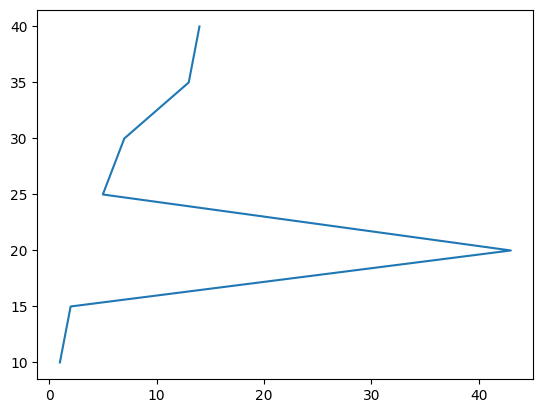

In [4]:
import matplotlib.pyplot as plt
x = [1, 2, 43, 5, 7, 13, 14]
y = [10, 15, 20, 25, 30, 35, 40]
plt.plot(x, y)
plt.show()

In [6]:
!pip install wordcloud

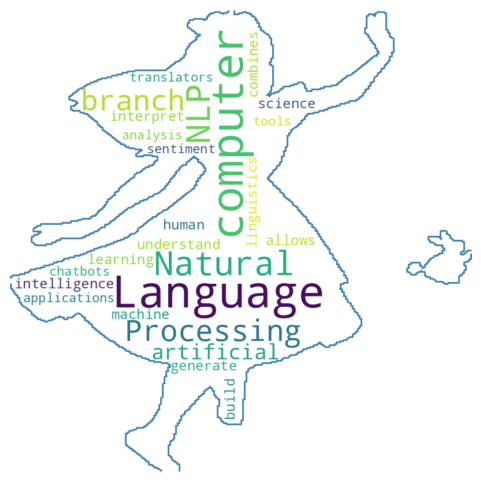

✅ ذخیره شد: /content/wordcloud_alice_style.png


In [13]:
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("/content/sphx_glr_masked_002.png").convert("L")

mask = np.array(img)
mask = np.where(mask > 128, 255, 0).astype("uint8")

ys, xs = np.where(mask == 0)
x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()
mask_cropped = mask[y_min:y_max+1, x_min:x_max+1]

alice_mask_img = Image.fromarray(mask_cropped)
alice_mask_img = alice_mask_img.resize((800, 800))
alice_mask = np.array(alice_mask_img)

text = """
NLP, or Natural Language Processing, is a branch of artificial intelligence
that allows computers to understand, interpret, and generate human language.
It combines linguistics, computer science, and machine learning to build
applications such as chatbots, translators, and sentiment analysis tools.
NLP, or Natural Language Processing, is a branch of artificial intelligence
that allows computers to understand, interpret, and generate human language.
It combines linguistics, computer science, and machine learning to build
applications such as chatbots, translators, and sentiment analysis tools.
"""

stopwords = set(STOPWORDS)

wc = WordCloud(
    background_color="white",
    max_words=2000,
    mask=alice_mask,
    stopwords=stopwords,
    contour_width=3,
    contour_color="steelblue",
    colormap="viridis"
)

wc.generate(text)

plt.figure(figsize=(6, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("/content/wordcloud_alice_style.png")
print("✅ ذخیره شد: /content/wordcloud_alice_style.png")

In [3]:
!pip install gensim python-crfsuite fasttext flashtext && pip install hazm --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.8 MB/s eta 0:00:00
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498212 sha256=9fac5e80a56cbda19f885b2f7a0d45365dc29056deb421c4061f7d1f9b4635fc
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=86e0f137e44bb5989f34908e3fbe7d03ac9f3e25e5c4e804f8191ce90bb876dd
  Stored in directory: /root/.cache/

Saving IranNastaliq.ttf to IranNastaliq.ttf


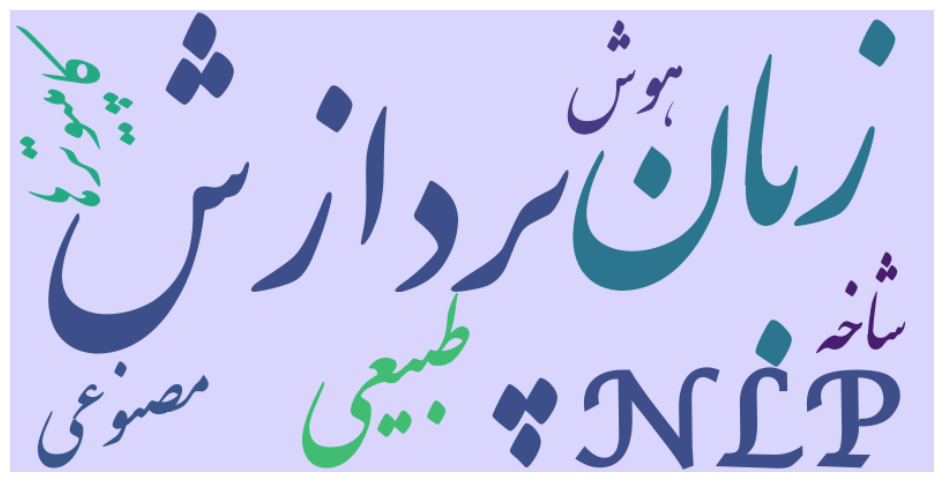

In [8]:
from wordcloud import WordCloud
from google.colab import files
import matplotlib.pyplot as plt
from hazm import stopwords_list, word_tokenize

text = '''
پردازش زبان طبیعی (NLP) یک شاخه از هوش مصنوعی است که به کامپیوترها امکان می‌دهد...
'''

# Upload font
uploaded = files.upload()
font_path = list(uploaded.keys())[0]

# Stopwords
fa_stops = set(stopwords_list())
extra_stops = {"است", "را", "که", "می‌شود", "می‌کند", "برای", "با", "این"}
fa_stops |= extra_stops

# Tokenize + clean
tokens = word_tokenize(text)
clean_text = " ".join([t for t in tokens if t not in fa_stops])

# Create word cloud
word_cloud = WordCloud(
    width=800,
    height=400,
    background_color='#d9d5fc',
    font_path=font_path,
    colormap='viridis'
).generate(clean_text)

# Show
plt.figure(figsize=(12, 6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Save
word_cloud.to_file("wordcloud_fa.png")